In [1]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os
import pickle
from datetime import datetime
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config, forecast_output_saver

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
logging.basicConfig(level=logging.INFO)


/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [3]:
%load_ext autoreload
%autoreload 2

### Data saving for plotting purposes

In [3]:
polished_path = f"results/polished_outputs/{datetime.now().strftime('%Y%m%d_%H%M%S')}/forecast_outputs.pkl"
os.makedirs(os.path.dirname(polished_path), exist_ok=True)

### Samples from all distributions separate for each model


In [7]:
polished_path = f"results/polished_outputs/{datetime.now().strftime('%Y%m%d_%H%M%S')}/forecast_outputs.pkl"
os.makedirs(os.path.dirname(polished_path), exist_ok=True)

model_repertoire = {
    "Chronos2": {"name": "Chronos2", "params": { "batch_size": 64}},
    # "Moirai": {"name": "Moirai", "params": {"repo_id": "Salesforce/moirai-1.1-R-large", "batch_size": 64}},
    "Toto": {"name": "Toto", "params": {"context_length": 4_096, "batch_size": 64}},
    # "Sundial": {"name": "Sundial", "params": { "batch_size": 64}},
}

config_dict = {
    "paths": {
        "storage_path": "data/simpletime/datasets_10",
        "output_path": "results"
    },
    "forecaster": None,
    "evaluation": {
        "to_univariate": False,
        "show_plot": False,
        "eval_substr": "dim0"
    },
}

for multivariate in [True]:
    multivariate_str = "Multivariate" if multivariate else "Univariate"
        
    for model_name in model_repertoire.keys():
        config_dict["forecaster"] = {
            "name": "MedianEnsemble",
            "max_length": 512,
            "models": [model_repertoire[model_name]],
            "alias": f"{model_name}-{multivariate_str}-Full-Simpletime" # An identifier for your ensemble
        }
        config_dict["experiment_name"] = f"simpletime_{multivariate_str}_Full"
        config_dict["evaluation"]["to_univariate"] = not multivariate
        
        config = load_config(config_dict=config_dict) # config_path

        # --- Set up the evaluation pipeline ---
        pipeline = TsPipeline(config)
        # print(pipeline.get_forecast_horizons())
        pipeline.run(skip_existing=False, num_plots=1)
        # pipeline.get_results()
        agg_output_pickle = forecast_output_saver(pipeline, multivariate_str, model_name, polished_path)
        print('Datasets: ', agg_output_pickle[multivariate_str][model_name].keys())
        

INFO:ts_toolkit.pipeline.runner:No datasets specified in config.datasets. Discovering datasets from: /home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_10
INFO:ts_toolkit.pipeline.runner:Discovered datasets: ['multivariate_lagged/growing_sine', 'multivariate_lagged/student_t', 'multivariate_lagged/poisson', 'multivariate_lagged/lognormal', 'multivariate_lagged/constant', 'multivariate_lagged/garch', 'multivariate_lagged/ma', 'multivariate_lagged/binary', 'multivariate_lagged/random_walk', 'multivariate_lagged/normal', 'multivariate_lagged/arma', 'multivariate_lagged/sine', 'multivariate_lagged/logistic', 'multivariate_lagged/uniform', 'multivariate_lagged/fourier', 'multivariate_lagged/piecewise_constant', 'multivariate_lagged/laplace', 'multivariate_lagged/cauchy', 'multivariate_lagged/impulse', 'multivariate_lagged/sarima', 'multivariate_lagged/linear', 'multivariate_lagged/pink_noise', 'multivariate_lagged/ar', 'multivariate_lagged/markov_chain', 'multivariate_lagged/

Evaluating Datasets:   0%|          | 0/108 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
10it [00:00, 534.61it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/growing_sine have been written to /home/nafiseh/GitHub/timeseries-research/results/simpletime_Multivariate_Full_20260212-163129/Chronos2-Multivariate-Full-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/results/simpletime_Multivariate_Full_20260212-163129/Chronos2-Multivariate-Full-Simpletime/simpletime_Multivariate_Full_20260212-163129_config.yaml
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
10it [00:00, 611.98it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/student_t have been written to /home/nafiseh/GitHub/timeseries-research/results/simpletime_Multivariate_Full_20260212-163129/Chronos2-Multivariate-Full-Si

Datasets:  dict_keys(['multivariate_lagged/growing_sine', 'multivariate_lagged/student_t', 'multivariate_lagged/poisson', 'multivariate_lagged/lognormal', 'multivariate_lagged/constant', 'multivariate_lagged/garch', 'multivariate_lagged/ma', 'multivariate_lagged/binary', 'multivariate_lagged/random_walk', 'multivariate_lagged/normal', 'multivariate_lagged/arma', 'multivariate_lagged/sine', 'multivariate_lagged/logistic', 'multivariate_lagged/uniform', 'multivariate_lagged/fourier', 'multivariate_lagged/piecewise_constant', 'multivariate_lagged/laplace', 'multivariate_lagged/cauchy', 'multivariate_lagged/impulse', 'multivariate_lagged/sarima', 'multivariate_lagged/linear', 'multivariate_lagged/pink_noise', 'multivariate_lagged/ar', 'multivariate_lagged/markov_chain', 'multivariate_lagged/sawtooth', 'multivariate_lagged/exponential', 'multivariate_lagged/skew_normal', 'multivariate_lagged/chirp', 'multivariate_lagged/staircase', 'multivariate_lagged/triangle', 'multivariate_lagged/gbm', 

Evaluating Datasets:   0%|          | 0/108 [00:00<?, ?it/s]

INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100%|██████████| 1/1 [00:10<00:00, 10.62s/it]
10it [00:00, 536.19it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/growing_sine have been written to /home/nafiseh/GitHub/timeseries-research/results/simpletime_Multivariate_Full_20260212-163129/simpletime_Multivariate_Full_20260212-164416/Toto-Multivariate-Full-Simpletime/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/results/simpletime_Multivariate_Full_20260212-163129/simpletime_Multivariate_Full_20260212-164416/Toto-Multivariate-Full-Simpletime/simpletime_Multivariate_Full_20260212-164416_config.yaml
INFO:ts_toolkit.pipeline.eval:Input: 2000-09-12T00:00:00.000000, label: 2000-09-12T00:00:00.000000, prediction length: 30
100%|██████████| 1/1 [00:09<00:00,  9.79s/it]
10it [00:00, 599.94it/s]
INFO:ts_toolkit.pipeline.eval:Results for 

Datasets:  dict_keys(['multivariate_lagged/growing_sine', 'multivariate_lagged/student_t', 'multivariate_lagged/poisson', 'multivariate_lagged/lognormal', 'multivariate_lagged/constant', 'multivariate_lagged/garch', 'multivariate_lagged/ma', 'multivariate_lagged/binary', 'multivariate_lagged/random_walk', 'multivariate_lagged/normal', 'multivariate_lagged/arma', 'multivariate_lagged/sine', 'multivariate_lagged/logistic', 'multivariate_lagged/uniform', 'multivariate_lagged/fourier', 'multivariate_lagged/piecewise_constant', 'multivariate_lagged/laplace', 'multivariate_lagged/cauchy', 'multivariate_lagged/impulse', 'multivariate_lagged/sarima', 'multivariate_lagged/linear', 'multivariate_lagged/pink_noise', 'multivariate_lagged/ar', 'multivariate_lagged/markov_chain', 'multivariate_lagged/sawtooth', 'multivariate_lagged/exponential', 'multivariate_lagged/skew_normal', 'multivariate_lagged/chirp', 'multivariate_lagged/staircase', 'multivariate_lagged/triangle', 'multivariate_lagged/gbm', 

In [8]:
polished_path

'results/polished_outputs/20260212_163129/forecast_outputs.pkl'

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle 
polished_path = 'results/polished_outputs/20260212_163129/forecast_outputs.pkl'

with open(polished_path, "rb") as f:
    output_data = pickle.load(f)

In [11]:
from ts_toolkit.pipeline.viz_utils import DISTRIBUTIONS
    
for multivariate_str in output_data.keys():
    for model_name, model_data in output_data[multivariate_str].items():
        # Collect keys to remove
        keys_to_remove = [
            dataset_name
            for dataset_name in model_data.keys()
            if dataset_name.split('/')[-1] in DISTRIBUTIONS['Autocorrelated Processes']
        ]
        # Remove the keys after iteration
        for key in keys_to_remove:
            del output_data[multivariate_str][model_name][key]

Number of datasets to plot: 84
multivariate_lagged/growing_sine: growing_sine_sample_000007 selected.
multivariate_lagged/student_t: student_t_sample_000005 selected.
multivariate_lagged/poisson: poisson_sample_000003 selected.
multivariate_lagged/lognormal: lognormal_sample_000006 selected.
multivariate_lagged/constant: constant_sample_000001 selected.
multivariate_lagged/binary: binary_sample_000006 selected.
multivariate_lagged/sine: sine_sample_000003 selected.
multivariate_lagged/logistic: logistic_sample_000002 selected.
multivariate_lagged/uniform: uniform_sample_000008 selected.
multivariate_lagged/fourier: fourier_sample_000008 selected.
multivariate_lagged/piecewise_constant: piecewise_constant_sample_000000 selected.
multivariate_lagged/laplace: laplace_sample_000006 selected.
multivariate_lagged/cauchy: cauchy_sample_000000 selected.
multivariate_lagged/impulse: impulse_sample_000002 selected.
multivariate_lagged/linear: linear_sample_000008 selected.
multivariate_lagged/sa

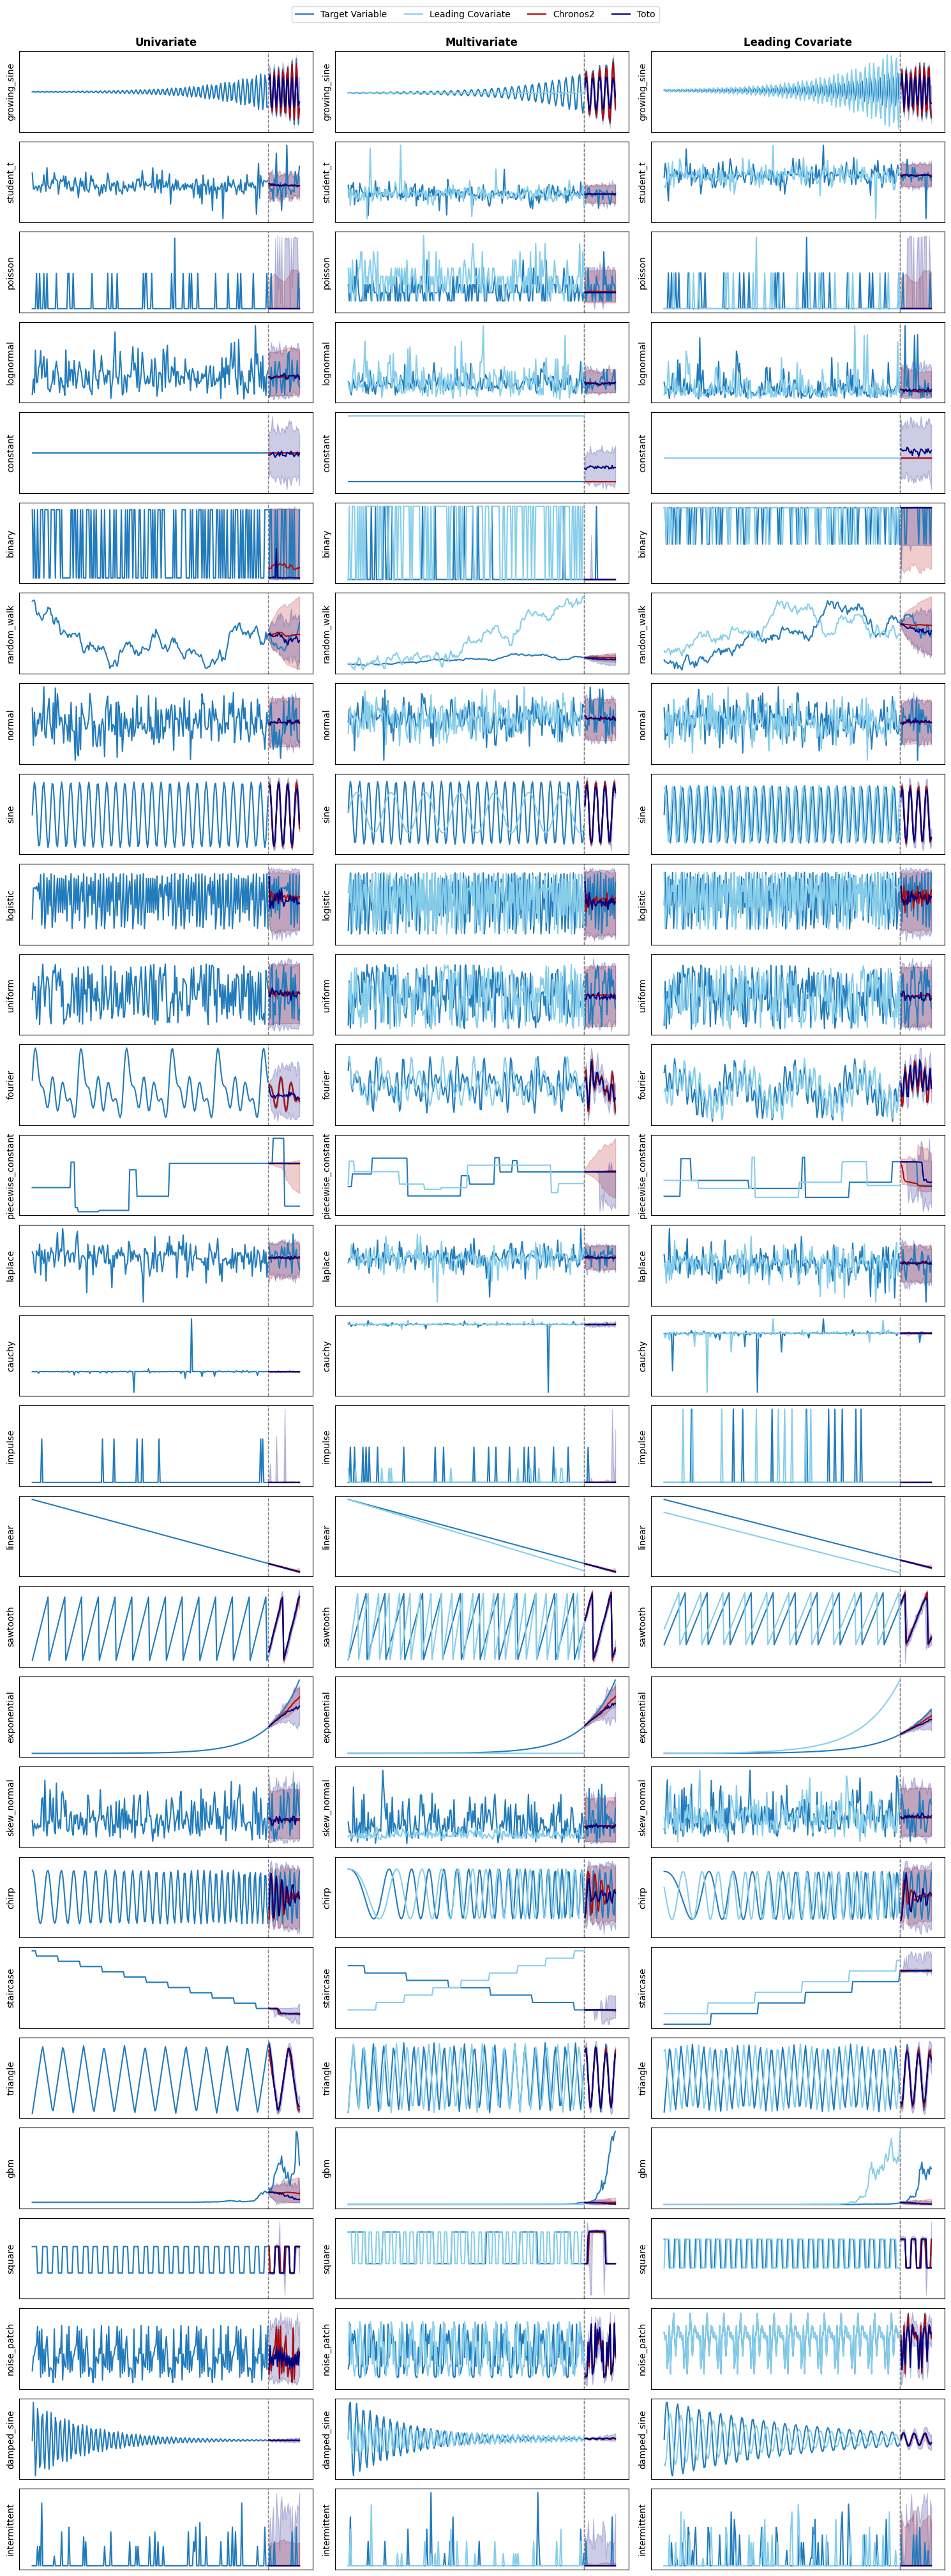

In [12]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from ts_toolkit.pipeline.visualization import polished_grid_plot
from ts_toolkit.pipeline.viz_utils import colors

# polished_grid_plot(output_data, colors, shade=True, selected_data_ids={}, figsize=(15, 30))

shade = True

selected_data_ids = {
    "multivariate_lagged/normal": "normal_sample_000002",
    "multivariate_lagged/random_walk": "random_walk_sample_000003",
    "multivariate_lagged/intermittent": "intermittent_sample_000000",
    "univariate/linear": "linear_sample_000004",
    "univariate/exponential": "exponential_sample_000000",
    "univariate/staircase": "staircase_sample_000004",
    "univariate/sine": "sine_sample_000008",
    "univariate/fourier": "fourier_sample_000004",
    "univariate/growing_sine": "growing_sine_sample_000007",
}
polished_grid_plot(
    output_data, colors, shade=shade, selected_data_ids=selected_data_ids, 
    flatten=False, figsize=(15, 40), num_fig_cols=3, legend_ncol=5, bbox_to_anchor=(0.5, 1.01),
    save_path='results_shared/TSALM2025_paper/simpletime_all_gridplot.pdf'
)
